### Analysing results from individual experiments

This notebook contains analysis of the results created throught the experiment in quantum_representation.ipynb. It impors the log files in this directory.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Import datasets and concatenate them

In [4]:
first_df = pd.read_csv("Chromosome_decoding_test_measurements_improved.csv").drop(columns=["Unnamed: 0"])
log_data = first_df
#first_df["Method"] = "Hash New 2"
#second_df = pd.read_csv("Chromosome_decoding_test_measurements.csv").drop(columns=["Unnamed: 0"])
#second_df = second_df[~second_df["Method"].isin(["Hash base", "Hash New"])]
# Concatenate datasets
#log_data = pd.concat([first_df, second_df])

<Axes: title={'center': 'Time complexity for conversion methods'}, xlabel='N', ylabel='Decoding_time'>

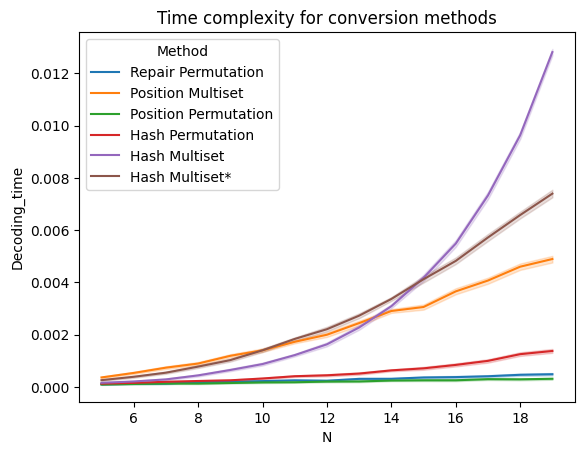

In [5]:
plt.title("Time complexity for conversion methods")
sns.lineplot(log_data, x="N", y="Decoding_time", hue="Method")

An important aspect of the conversion between binary and integer representations is the how the probability of reaching each solution in the search space. In the follwoing cells, the distribution of solutions in the search spaces are examined.

Read data from disk

In [3]:
dataset_dtypes = pd.read_csv("Chromosome_decoding_test_redundancy_jm3_dtypes.csv").drop(columns=["Unnamed: 0"])
df_redundancy = pd.read_csv("Chromosome_decoding_test_redundancy_jm3.csv", dtype=dataset_dtypes["0"].to_numpy()).drop(columns=["Unnamed: 0"])
df_redundancy["String Length"] = df_redundancy["Binary"].apply(lambda x: len(str(x)))

Next, an Id value is assigned to each unique permutation

In [4]:
temp_permutation_id = pd.Series(df_redundancy["Permutation"].unique()).reset_index().rename(columns={0 : "Permutation", "index" : "PermId"})
df_redundancy = df_redundancy.merge(right=temp_permutation_id, on="Permutation")

An important aspect of the conversion between binary and integer representations is how the probability of reaching each solution in the search space. In the follwoing cells, the distribution of solutions in the search spaces are examined.

In [4]:
unique_df = df_redundancy.groupby(["Method", "N", "String Length"]).agg(lambda x: len(np.unique(x)))
unique_df

,,,Permutation,Binary,Binary_value,Decoding_time,PermId
Method,N,String Length,,,,,
Hash Multiset,3,14,1680,16384,16384,9328,1680
Hash Multiset*,3,14,1680,16384,16384,10769,1680
Hash Permutation,3,18,216,256300,256300,9285,216
Position Multiset,3,18,1680,256310,256310,12915,1680
Position Permutation,3,18,216,256399,256399,8218,216
Repair Permutation,3,18,216,256401,256401,8571,216


Note that the Hash methods for the Multiset representation uses significantly less binary strings to represent the same amount of Permutations of a Multiset. It is also important to note that the Permutation covers significantly less of the search space.

In [5]:
df_redundancy.groupby(["Method"])[["Permutation", "PermId"]].value_counts()

Method              Permutation  PermId
Hash Multiset       100210122    623       684
                    200021112    825       684
                    200211210    1359      682
                    120102021    195       680
                    212001201    730       680
                                          ... 
Repair Permutation  120210210    231       845
                    120120120    343       829
                    210210210    302       815
                    120210120    472       800
                    120120210    218       794
Name: count, Length: 5688, dtype: int64

In [6]:
temp_df = df_redundancy.groupby(["Method", "PermId"])["Permutation"].value_counts().reset_index()
temp_df.groupby(["Method"]).agg({"count" : ["min", "max", "std"]})

count                    
                       min    max          std
Method                                        
Hash Multiset          494    684    36.254057
Hash Multiset*         494    689    35.569298
Hash Permutation      3732   5224   358.852255
Position Multiset       70   3650   374.572220
Position Permutation   234  30795  3908.703153
Repair Permutation     794  30673  3911.514437

In [7]:
unique_2 = df_redundancy.groupby(["Method", "Permutation", "PermId"]).agg(lambda x: len(np.unique(x)))#len(np.unique(x)))
unique_2


N  Binary  Binary_value  Decoding_time  \
Method             Permutation PermId                                           
Hash Multiset      000111222   1181    1       9             9             28   
                   000112122   60      1       9             9             22   
                   000112212   1309    1       9             9             23   
                   000112221   1402    1       9             9             16   
                   000121122   893     1       9             9             26   
...                                   ..     ...           ...            ...   
Repair Permutation 210210021   172     1     421           421             53   
                   210210102   54      1     351           351             40   
                   210210120   325     1     212           212             33   
                   210210201   193     1     350           350             55   
                   210210210   302     1     209           209             25   

                                       String Length  
Method             Permutation PermId                 
Hash Multiset      000111222   1181                1  
                   000112122   60                  1  
                   000112212   1309                1  
                   000112221   1402                1  
                   000121122   893                 1  
...                                              ...  
Repair Permutation 210210021   172                 1  
                   210210102   54                  1  
                   210210120   325                 1  
                   210210201   193                 1  
                   210210210   302                 1  

[5688 rows x 5 columns]

In [8]:
unique_2.reset_index(drop=False).groupby("Method").agg({"Binary" : ["max", "min", "std"]})

Binary                  
                        max  min          std
Method                                       
Hash Multiset            10    9     0.431758
Hash Multiset*           10    9     0.431758
Hash Permutation       1313  971    91.467539
Position Multiset       956   19    95.827560
Position Permutation   7845   64  1001.511761
Repair Permutation     7819  208  1001.243712

The follwoing histograms visualize the frequency of each permutations in the test data.

In [9]:
plot_df_2 = df_redundancy[["PermId", "Binary_value", "Method"]]

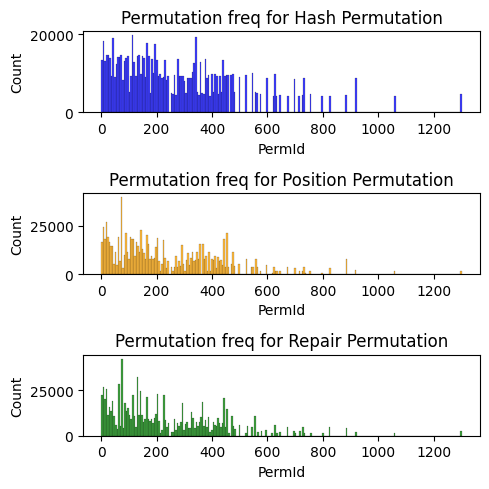

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Permutation"])], x="PermId", color="blue", ax=ax[0])
ax[0].set_title("Permutation freq for Hash Permutation")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Position Permutation"])], x="PermId", color="orange", ax=ax[1])
ax[1].set_title("Permutation freq for Position Permutation")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Repair Permutation"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Permutation freq for Repair Permutation")

plt.tight_layout()

From this plot we can see that the minimum frequency for any permutation looks to be higher for hash permutation  method. Note that the spacing comes from that the permutation ids were created for the muliset methods which cover significanly more of the search space. One can alos see that the search space somehow is groped together. Here it would be interesting to investigate the order in which the permutations were given id's to see if there is a pattern here.

it looks like the grouping of higher frequencies on the left is related to the fact that they are more probable and thus more likely to be among the first drawn permutations.

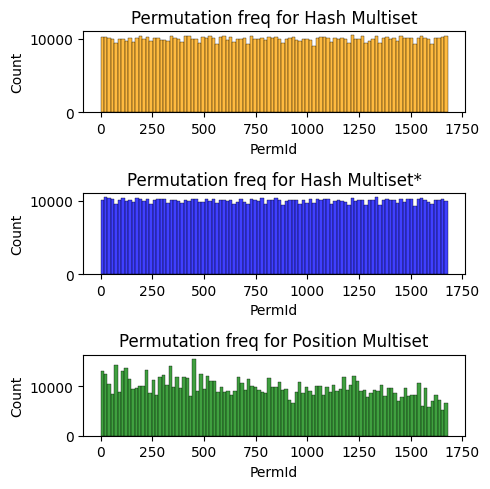

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(5, 5))
sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Multiset"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Permutation freq for Hash Multiset")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Multiset*"])], x="PermId", color="blue", ax=ax[1])
ax[1].set_title("Permutation freq for Hash Multiset*")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Position Multiset"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Permutation freq for Position Multiset")
plt.tight_layout()

The following plots show how many unique binary string there exists for each permutation

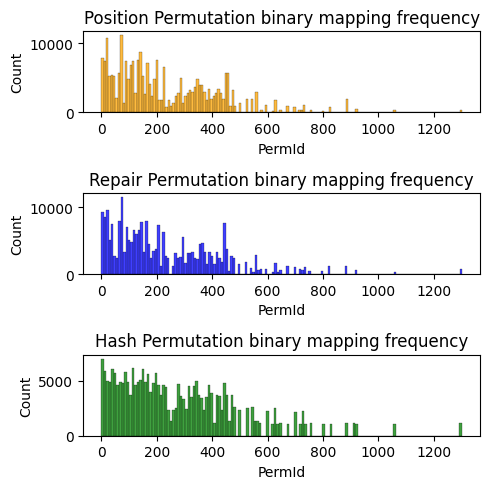

In [8]:
df_plot_1 = df_redundancy.drop_duplicates(["Method", "Binary"], keep="first")

fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Position Permutation"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Position Permutation binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Repair Permutation"])], x="PermId", color="blue", ax=ax[1])
ax[1].set_title("Repair Permutation binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Permutation"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Hash Permutation binary mapping frequency")

plt.tight_layout()

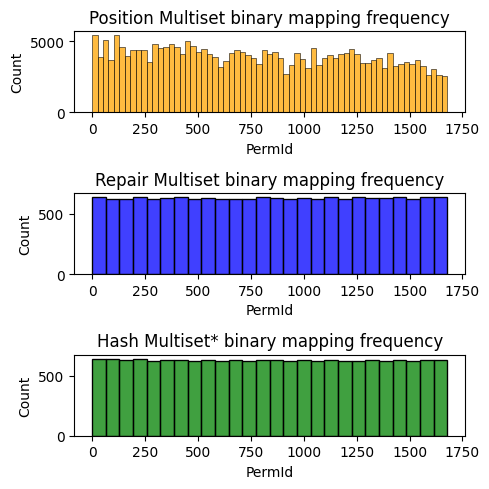

In [9]:
df_plot_1 = df_redundancy.drop_duplicates(["Method", "Binary"], keep="first")

fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Position Multiset"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Position Multiset binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Multiset"])], x="PermId", color="blue", ax=ax[1])
ax[1].set_title("Repair Multiset binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Multiset*"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Hash Multiset* binary mapping frequency")

plt.tight_layout()

Note how the frequency values are higher in the plot. This is explained by that the bins cover several permutations.

In [20]:
df_plot_1.groupby(["Method"])["PermId"].value_counts().reset_index().groupby(["Method"]).agg({"count" : ["min", "max", "std"]})

count                   
                       min   max          std
Method                                       
Hash Multiset            9    10     0.431758
Hash Multiset*           9    10     0.431758
Hash Permutation       971  1313    91.467539
Position Multiset       19   956    95.827560
Position Permutation    64  7845  1001.511761
Repair Permutation     208  7819  1001.243712

<Axes: xlabel='PermId', ylabel='Binary'>

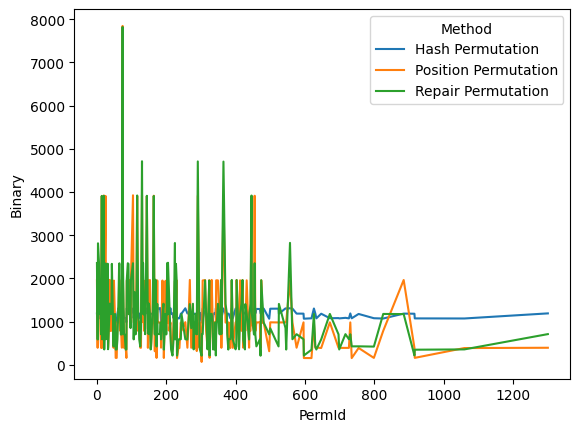

In [ ]:
plot_df_1 = unique_2.reset_index().reset_index()
sns.lineplot(data=plot_df_1[plot_df_1["Method"].isin(["Position Permutation", "Hash Permutation", "Repair Permutation"])], x="PermId", y="Binary", hue="Method")

<Axes: xlabel='PermId', ylabel='Binary'>

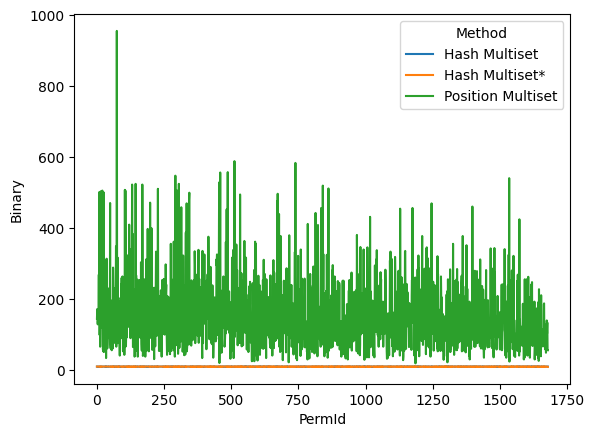

In [13]:
sns.lineplot(data=plot_df_1[plot_df_1["Method"].isin(["Hash Multiset", "Hash Multiset*", "Position Multiset"])], x="PermId", y="Binary", hue="Method")

One thing we can observe from the above is that, despite the number of unique binary strings for each permutation is significantly better for the hash functions, the frequency of each permutation ocuring is relatively good spaced for the position base also. Can this be explained with the theory of big numbers?